# Project Hail Mary: The Adrian Descent

**SoC '26 KernelMind Assignment 2**

This notebook accompanies the modular submission files: `env.py`, `agent.py`, `train.py`, `run.py`, `bonus_variable_spin.py`, and `report.md`.

# SoC '26 KernelMind Assignment 2 — The Adrian Descent

## 1. Deterministic baseline and analytics

### Terminal velocity if the spin-drive fails

For a falling probe, velocity is negative, so drag points upward. At terminal velocity, gravity and drag balance:

\[
|F_g|=F_{drag}
\]

\[
m g \left(1-\frac{h}{R_{Adrian}}\right)^2 = k_{drag} v_t^2
\]

\[
v_t = -\sqrt{\frac{m g \left(1-\frac{h}{R_{Adrian}}\right)^2}{k_{drag}}}
\]

At the target altitude \(h \approx 0\):

\[
v_t=-\sqrt{\frac{1000(13.7)}{2.0}}=-82.76\text{ m/s}
\]

At the 1000 m drop altitude, the radius correction is tiny and gives \(v_t \approx -82.76\text{ m/s}\) as well. This is far outside the safe target-catch limit of \(v \geq -3.0\text{ m/s}\). Therefore, a passive probe is destroyed. The control problem is difficult because the agent must allow descent but brake hard enough near the target.

### Maximum net force and acceleration with thrust ON

At \(h=1000\text{ m}\), \(v=0\), and full thrust ON:

\[
F_g=-1000(13.7)\left(1-\frac{1000}{10,700,000}\right)^2=-13697.44\text{ N}
\]

\[
F_{net}=25000-13697.44=11302.56\text{ N}
\]

\[
a=\frac{F_{net}}{m}=11.30\text{ m/s}^2
\]

The thrust is strong enough to accelerate the probe upward against Adrian gravity. This creates a reward-design danger: if crashing is punished but hovering/flying upward is not punished enough, the agent can become cowardly and avoid the mission instead of landing.

## 2. MDP formulation and wind memory

The state is:

\[
S_t=(h_t, v_t, w_t)
\]

where \(w_t\in\{0,1,2\}\):

- 0 = Calm = \(1.0\times\) drag
- 1 = Gusty = \(1.5\times\) drag
- 2 = Adrian Gale = \(2.5\times\) drag

The transition probability matrix used in the code is:

\[
P=
\begin{bmatrix}
0.86 & 0.12 & 0.02 \\
0.15 & 0.70 & 0.15 \\
0.04 & 0.22 & 0.74
\end{bmatrix}
\]

Rows represent the current wind state and columns represent the next wind state. This simulates weather momentum because the next wind state depends heavily on the present wind state. Calm usually stays calm, gusty usually stays gusty, and gales often persist. A random 3-sided die would make every time step independent, causing unrealistically jittery weather with no storm continuity.

## 3. Discretization and Q-learning

The raw state variables \(h\) and \(v\) are continuous, so the agent discretizes them into buckets with `np.digitize`. The submitted binary-thrust agent uses:

\[
50\text{ altitude buckets}\times 50\text{ velocity buckets}\times 3\text{ wind states}\times 2\text{ actions}=15000\text{ Q-values}
\]

The Bellman update is:

\[
Q(s,a)\leftarrow Q(s,a)+\alpha\left[r + \gamma \max_{a'}Q(s',a')-Q(s,a)\right]
\]

If the transition is terminal, the future term is removed:

\[
Q(s,a)\leftarrow Q(s,a)+\alpha\left[r-Q(s,a)\right]
\]

## 4. Exploration vs. exploitation

With \(\epsilon_0=1.0\) and decay factor \(0.999\):

\[
\epsilon_{5000}=1.0(0.999)^{5000}=0.006721
\]

So after 5000 episodes, the agent is mostly exploiting. In the code, an `epsilon_min` floor is retained so exploration does not become exactly zero during training.

## 5. Reward shaping and the cowardly-agent pitfall

If the crash penalty is huge but fuel is almost free, the agent may learn to fire the engine forever, hover, or fly back upward instead of completing the mission. If the only reward is a sparse terminal \(+1000\) for success, most early episodes end in crash or timeout and the agent receives very little useful credit-assignment information.

The implemented reward structure is:

- Time cost: \(-0.02\) per step.
- Engine burn cost: \(-0.05\times\text{thrust fraction}\) per step.
- Descent progress: \(+0.010\times\max(h_t-h_{t+1},0)\).
- Velocity-profile shaping: \(-0.050\times |v-v_{target}(h)|\), where

\[
v_{target}(h)=-\max(1.5,\min(60.0,0.08h+1.5))
\]

- Near-target overspeed penalty for \(h<150\) and \(v<-3\):

\[
-0.150(|v|-3)^2
\]

- Upward-escape penalty: \(-0.30v\) when \(v>0\).
- Soft catch terminal reward:

\[
+2000-20|v|
\]

- Crash terminal penalty:

\[
-2500-5\max(0,|v|-3)^2
\]

- Runaway terminal penalty:

\[
-3000-\max(0,h-1200)
\]

- Timeout terminal penalty:

\[
-3500-2h-10|v|
\]

This makes the safest high-reward behavior a controlled descent, not endless hovering.

## 6. Training and evaluation

`train.py` trains for 15,000 episodes by default, tracks total reward, landing result, success flag, and impact velocity, then saves:

- `learning_curve.png`
- `training_metrics.csv`
- `adrian_q_table.npz`

`run.py` loads the saved Q-table and runs a greedy \(\epsilon=0\) test episode using the ASCII renderer.

## 7. Why the reward curve asymptotes below the theoretical maximum

A perfect unpenalized score is mathematically impossible because the probe cannot land without spending time, and almost always must spend some fuel. The wind process is stochastic, so the agent must keep correcting its descent. The state space is discretized, so the Q-table cannot represent infinitely precise altitude and velocity control. Finally, the probe reaches the target with some nonzero impact velocity, so the terminal reward is reduced by the velocity term.

## 8. Bonus: variable spin-drive

For the bonus setting, the action space becomes:

- 0 = OFF
- 1 = 50% thrust
- 2 = 100% thrust

The Q-table size changes from:

\[
50\times50\times3\times2=15000
\]

to:

\[
50\times50\times3\times3=22500
\]

That is a 50% increase in Q-values. A 50% thrust level can help because the agent no longer has to alternate violently between full OFF and full ON; it can make softer corrections near the catch zone. However, the larger action space increases exploration burden and can require more episodes to converge.


## Implementation usage

The full implementation is split into clean modules for submission. The next cells show how to run the environment and agent.

In [1]:
from env import ProbeEnv, render_probe_ascii
from agent import ProbeAgent, AgentConfig
from train import train
from run import run_greedy

env = ProbeEnv()
agent = ProbeAgent(n_actions=env.n_actions)
print('Environment initial state:', env.reset())
print('Q-table shape:', agent.q_table.shape)
print('Q-table entries:', agent.q_table.size)

Environment initial state: (1000.0, 0.0, 0)
Q-table shape: (50, 50, 3, 2)
Q-table entries: 15000


In [2]:
# Full training command used for the final included artifacts.
# summary = train(episodes=15_000, seed=7, out_dir='.')
# print(summary)

print('The packaged learning_curve.png, training_metrics.csv, and adrian_q_table.npz were generated with 15,000 episodes.')

The packaged learning_curve.png, training_metrics.csv, and adrian_q_table.npz were generated with 15,000 episodes.


## Included 15,000-episode learning curve

The plot below was generated by `train.py` and shows moving-average reward and landing success rate.

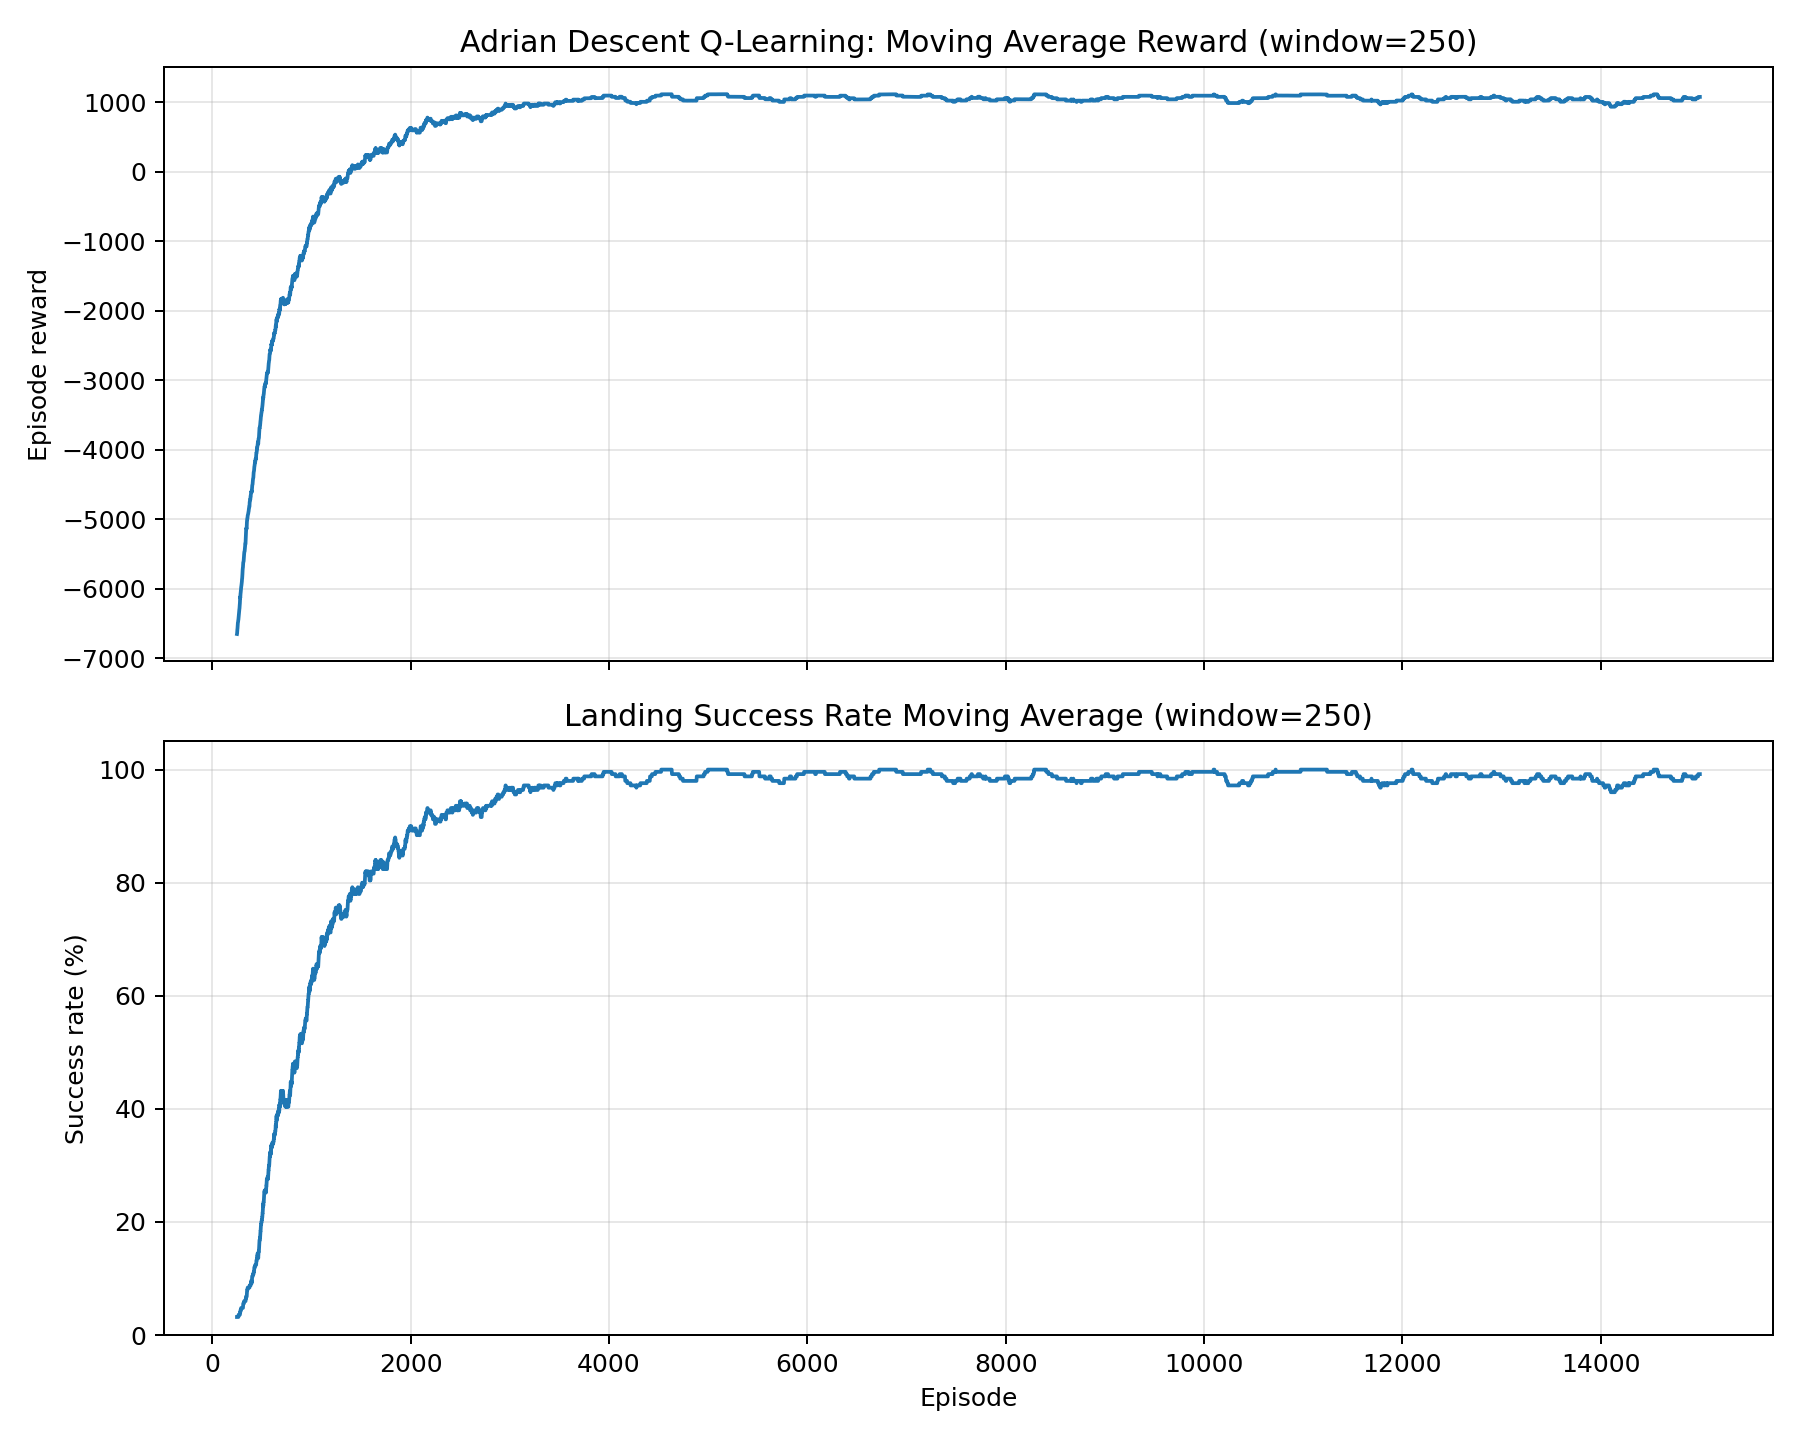

In [3]:
from IPython.display import Image
Image('learning_curve.png')

In [4]:
# Greedy evaluation without terminal animation.
result = run_greedy(q_table_path='adrian_q_table.npz', render=False, seed=123)
print(result)

{'result': 'success', 'steps': 522, 'final_altitude': -0.13377123311299455, 'impact_velocity': -2.0638710119706873, 'last_action': 0, 'total_reward': 1106.546726150468}


## Bonus challenge usage

The environment supports a variable spin-drive action space directly.

In [5]:
bonus_env = ProbeEnv(thrust_levels=(0.0, 0.5, 1.0))
bonus_agent = ProbeAgent(n_actions=bonus_env.n_actions)
print('Bonus thrust levels:', bonus_env.thrust_levels)
print('Bonus Q-table shape:', bonus_agent.q_table.shape)
print('Bonus Q-table entries:', bonus_agent.q_table.size)

Bonus thrust levels: (0.0, 0.5, 1.0)
Bonus Q-table shape: (50, 50, 3, 3)
Bonus Q-table entries: 22500
